### 1. imports

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
plt.rcParams['figure.figsize'] = (4.5, 3.0)

### 2. 파라메터 학습과정

In [4]:
torch.manual_seed(43052)
x,_ = torch.randn(100).sort()
eps = torch.randn(100)*0.5
X = torch.stack([torch.ones(100),x],axis=1)
W = torch.tensor([[2.5],[4.0]])
y = X@W + eps.reshape(100,1)
x = X[:,[1]]

#### A. 학습과정 print

In [7]:
What = torch.tensor([[-5.0],[10.0]], requires_grad=True)
alpha = 0.001
print(f"시작값 = {What.data.reshape(-1)}")
for epoc in range(30):
    yhat = X @ What
    loss = torch.sum((y-yhat)**2)
    loss.backward()
    What.data = What.data - alpha * What.grad
    print(f'loss = {loss:.2f} \n업데이트폭 = {-alpha * What.grad.reshape(-1)} \n업데이트결과: {What.data.reshape(-1)}')
    What.grad = None

시작값 = tensor([-5., 10.])
loss = 8587.69 
업데이트폭 = tensor([ 1.3423, -1.1889]) 
업데이트결과: tensor([-3.6577,  8.8111])
loss = 5675.21 
업데이트폭 = tensor([ 1.1029, -0.9499]) 
업데이트결과: tensor([-2.5548,  7.8612])
loss = 3755.64 
업데이트폭 = tensor([ 0.9056, -0.7596]) 
업데이트결과: tensor([-1.6492,  7.1016])
loss = 2489.58 
업데이트폭 = tensor([ 0.7431, -0.6081]) 
업데이트결과: tensor([-0.9061,  6.4935])
loss = 1654.04 
업데이트폭 = tensor([ 0.6094, -0.4872]) 
업데이트결과: tensor([-0.2967,  6.0063])
loss = 1102.32 
업데이트폭 = tensor([ 0.4995, -0.3907]) 
업데이트결과: tensor([0.2028, 5.6156])
loss = 737.84 
업데이트폭 = tensor([ 0.4091, -0.3136]) 
업데이트결과: tensor([0.6119, 5.3020])
loss = 496.97 
업데이트폭 = tensor([ 0.3350, -0.2519]) 
업데이트결과: tensor([0.9469, 5.0501])
loss = 337.71 
업데이트폭 = tensor([ 0.2742, -0.2025]) 
업데이트결과: tensor([1.2211, 4.8477])
loss = 232.40 
업데이트폭 = tensor([ 0.2243, -0.1629]) 
업데이트결과: tensor([1.4454, 4.6848])
loss = 162.73 
업데이트폭 = tensor([ 0.1834, -0.1311]) 
업데이트결과: tensor([1.6288, 4.5537])
loss = 116.63 
업데이트폭 = tensor([ 0.1

#### B. yhat의 관점에서 시각화

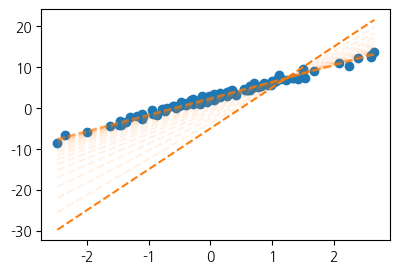

In [8]:
What = torch.tensor([[-5.0],[10.0]],requires_grad=True)
alpha = 0.001
plt.plot(x,y,'o',label = "observed")
fig = plt.gcf()
ax = fig.gca()
ax.plot(x,X@What.data,'--',color="C1")
for epoc in range(30):
    yhat = X @ What
    loss = torch.sum((y-yhat)**2)
    loss.backward()
    What.data = What.data - alpha * What.grad
    ax.plot(x,X@What.data,'--',color="C1",alpha=0.1)
    What.grad = None

#### C. loss의 관점에서 시각화

In [9]:
def plot_loss():
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    w0 = np.arange(-6, 11, 0.5) 
    w1 = np.arange(-6, 11, 0.5)
    W1,W0 = np.meshgrid(w1,w0)
    LOSS=W0*0
    for i in range(len(w0)):
        for j in range(len(w1)):
            LOSS[i,j]=torch.sum((y-w0[i]-w1[j]*x)**2)
    ax.plot_surface(W0, W1, LOSS, rstride=1, cstride=1, color='b',alpha=0.1)
    ax.azim = 30  ## 3d plot의 view 조절 
    ax.dist = 8   ## 3d plot의 view 조절 
    ax.elev = 5   ## 3d plot의 view 조절 
    ax.set_xlabel(r'$w_0$')  # x축 레이블 설정
    ax.set_ylabel(r'$w_1$')  # y축 레이블 설정
    ax.set_xticks([-5,0,5,10])  # x축 틱 간격 설정
    ax.set_yticks([-5,0,5,10])  # y축 틱 간격 설정
    plt.close(fig)  # 자동 출력 방지
    return fig

In [11]:
def l(w0hat,w1hat):
    yhat = w0hat + w1hat*x
    return torch.sum((y-yhat)**2)

/tmp/ipykernel_144216/2229765328.py:13: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 8   ## 3d plot의 view 조절


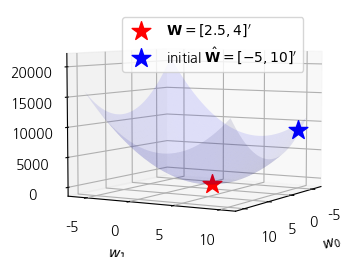

In [12]:
fig = plot_loss()
ax = fig.gca()
ax.scatter(2.5, 4, l(2.5,4), s=200, marker='*', color='red', label=r"${\bf W}=[2.5, 4]'$")
ax.scatter(-5, 10, l(-5,10), s=200, marker='*', color='blue', label=r"initial $\hat{\bf W}=[-5, 10]'$")
ax.legend()
fig

#### D. 애니메이션


In [18]:
from matplotlib import animation

In [19]:
plt.rcParams['figure.figsize'] = (7.5,2.5)
plt.rcParams["animation.html"] = "jshtml" 

In [20]:
def show_animation(alpha=0.001):
    ## 1. 히스토리 기록을 위한 list 초기화
    loss_history = [] 
    yhat_history = [] 
    What_history = [] 

    ## 2. 학습 + 학습과정기록
    What= torch.tensor([[-5.0],[10.0]],requires_grad=True)
    What_history.append(What.data.tolist())
    for epoc in range(30): 
        yhat=X@What ; yhat_history.append(yhat.data.tolist())
        loss=torch.sum((y-yhat)**2); loss_history.append(loss.item())
        loss.backward() 
        What.data = What.data - alpha * What.grad; What_history.append(What.data.tolist())
        What.grad = None    

    ## 3. 시각화 
    fig = plt.figure()
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')

    #### ax1: yhat의 관점에서.. 
    ax1.plot(x,y,'o',label=r"$(x_i,y_i)$")
    line, = ax1.plot(x,yhat_history[0],label=r"$(x_i,\hat{y}_i)$") 
    ax1.legend()
    #### ax2: loss의 관점에서.. 
    w0 = np.arange(-6, 11, 0.5) 
    w1 = np.arange(-6, 11, 0.5)
    W1,W0 = np.meshgrid(w1,w0)
    LOSS=W0*0
    for i in range(len(w0)):
        for j in range(len(w1)):
            LOSS[i,j]=torch.sum((y-w0[i]-w1[j]*x)**2)
    ax2.plot_surface(W0, W1, LOSS, rstride=1, cstride=1, color='b',alpha=0.1)
    ax2.azim = 30  ## 3d plot의 view 조절 
    ax2.dist = 8   ## 3d plot의 view 조절 
    ax2.elev = 5   ## 3d plot의 view 조절 
    ax2.set_xlabel(r'$w_0$')  # x축 레이블 설정
    ax2.set_ylabel(r'$w_1$')  # y축 레이블 설정
    ax2.set_xticks([-5,0,5,10])  # x축 틱 간격 설정
    ax2.set_yticks([-5,0,5,10])  # y축 틱 간격 설정
    ax2.scatter(2.5, 4, l(2.5,4), s=200, marker='*', color='red', label=r"${\bf W}=[2.5, 4]'$")
    ax2.scatter(-5, 10, l(-5,10), s=200, marker='*', color='blue')
    ax2.legend()
    def animate(epoc):
        line.set_ydata(yhat_history[epoc])
        ax2.scatter(np.array(What_history)[epoc,0],np.array(What_history)[epoc,1],loss_history[epoc],color='grey')
        fig.suptitle(f"alpha = {alpha} / epoch = {epoc}")
        return line

    ani = animation.FuncAnimation(fig, animate, frames=30)
    plt.close()
    return ani

In [21]:
ani = show_animation(alpha=0.001)
ani

/tmp/ipykernel_144216/464110397.py:36: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax2.dist = 8   ## 3d plot의 view 조절


#### E. 학습률($\alpha$) 다양하게

`-` $\alpha$가 너무 작아서 비효율적

In [22]:
show_animation(alpha=0.0001)

/tmp/ipykernel_144216/464110397.py:36: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax2.dist = 8   ## 3d plot의 view 조절


`-` $\alpha$ 가 크다고 무조건 좋은것도 아님

In [23]:
show_animation(alpha=0.0083)

/tmp/ipykernel_144216/464110397.py:36: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax2.dist = 8   ## 3d plot의 view 조절


`-` 수렴을 안할수도 있음

In [25]:
show_animation(alpha=0.0085)

/tmp/ipykernel_144216/464110397.py:36: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax2.dist = 8   ## 3d plot의 view 조절


`-` $\alpha$ 를 너무 크게함

In [26]:
show_animation(alpha=0.01)

/tmp/ipykernel_144216/464110397.py:36: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax2.dist = 8   ## 3d plot의 view 조절


---

In [27]:
plt.rcdefaults()
plt.rcParams['figure.figsize'] = 4.5,3.0 

### 3. SSE $\to$ MSE

`-` 학습률 선택하는 것이 중요

`-` 손실함수를 SSE로 설정하면 학습률 선택에서 비효율적

`-` $\to$ **MSE !!!**

`손실함수가 SSE일 때 코드`

In [28]:
What = torch.tensor([[-5.0],[10.0]],requires_grad = True)
for epoc in range(30):
    # step1: yhat 
    yhat = X@What 
    # step2: loss
    loss = torch.sum((y-yhat)**2)
    # step3: 미분
    loss.backward()
    # step4: update
    What.data = What.data - 0.001 * What.grad
    What.grad = None

In [29]:
What.data

tensor([[2.4290],
        [4.0144]])

`손실함수가  MSE일 때 코드`

In [30]:
What = torch.tensor([[-5.0],[10.0]],requires_grad = True)
for epoc in range(30):
    # step1: yhat 
    yhat = X@What 
    # step2: loss
    loss = torch.sum((y-yhat)**2)/100 # torch.mean((y-yhat)**2)
    # step3: 미분
    loss.backward()
    # step4: update
    What.data = What.data - 0.1 * What.grad
    What.grad = None

In [31]:
What.data

tensor([[2.4290],
        [4.0144]])

### 4. 파이토치식 코딩패턴 1

In [32]:
torch.manual_seed(43052)
x,_ = torch.randn(100).sort()
eps = torch.randn(100)*0.5
X = torch.stack([torch.ones(100),x],axis=1)
W = torch.tensor([[2.5],[4.0]])
y = X@W + eps.reshape(100,1)
x = X[:,[1]]

#### A. 기본 패턴 (★)

In [33]:
What = torch.tensor([[-5.0],[10.0]],requires_grad = True)
for epoc in range(30):
    # step1: yhat 
    yhat = X@What 
    # step2: loss
    loss = torch.sum((y-yhat)**2)/100
    # step3: 미분
    loss.backward()
    # step4: update
    What.data = What.data - 0.1 * What.grad
    What.grad = None

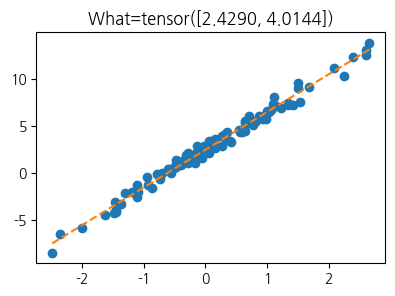

In [34]:
plt.plot(x,y,'o')
plt.plot(x,X@What.data,'--')
plt.title(f'What={What.data.reshape(-1)}');

#### B. Step2 loss값 계산 $\to$ `loss_fn` 이용

In [35]:
What = torch.tensor([[-5.0],[10.0]],requires_grad = True)
loss_fn = torch.nn.MSELoss()
for epoc in range(30):
    # step1: yhat 
    yhat = X@What 
    # step2: loss
    #loss = torch.sum((y-yhat)**2)/100
    loss = loss_fn(yhat,y) # 여기서는 큰 상관없지만 습관적으로 yhat을 먼저넣는 연습을 하자!!
    # step3: 미분
    loss.backward()
    # step4: update
    What.data = What.data - 0.1 * What.grad
    What.grad = None

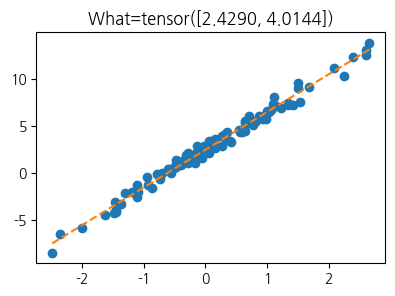

In [36]:
plt.plot(x,y,'o')
plt.plot(x,X@What.data,'--')
plt.title(f'What={What.data.reshape(-1)}');

#### C. Step3 yhat 계산 $\to$ `net` 이용

`-` 원래 방식

In [46]:
What = torch.tensor([[-5.0],[10.0]],requires_grad = True)
yhat= X@What
yhat[:5]

tensor([[-29.8211],
        [-28.6215],
        [-24.9730],
        [-21.2394],
        [-19.7919]], grad_fn=<SliceBackward0>)

In [47]:
# yhat = net(X) 
net = torch.nn.Linear(
    in_features=2, # X:(n,2) --> 2 
    out_features=1, # yhat:(n,1) --> 1 
    bias=False 
)

`-` **.T(전치를 꼭 해서 넣어줘야함)**

In [49]:
net.weight.data = torch.tensor([[-5.0], [10.0]]).T
net.weight

Parameter containing:
tensor([[-5., 10.]], requires_grad=True)

`-` 아래 값이 모두 같은 것을 알 수 있음

In [50]:
net(X)[:5]

tensor([[-29.8211],
        [-28.6215],
        [-24.9730],
        [-21.2394],
        [-19.7919]], grad_fn=<SliceBackward0>)

In [51]:
(X@What)[:5]

tensor([[-29.8211],
        [-28.6215],
        [-24.9730],
        [-21.2394],
        [-19.7919]], grad_fn=<SliceBackward0>)

In [52]:
(X@net.weight.T)[:5]

tensor([[-29.8211],
        [-28.6215],
        [-24.9730],
        [-21.2394],
        [-19.7919]], grad_fn=<SliceBackward0>)

`-` `loss_fn`, `net` 사용 코드

In [53]:
# step1을 위한 사전준비
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    bias=False
)
net.weight.data = torch.tensor([[-5.0,  10.0]])
# step2를 위한 사전준비
loss_fn = torch.nn.MSELoss()
for epoc in range(30):
    # step1: yhat
    # yhat = X@What 
    yhat = net(X)
    # step2: loss
    loss = loss_fn(yhat,y)
    # step3: 미분
    loss.backward()
    # step4: update
    net.weight.data = net.weight.data - 0.1 * net.weight.grad
    net.weight.grad = None

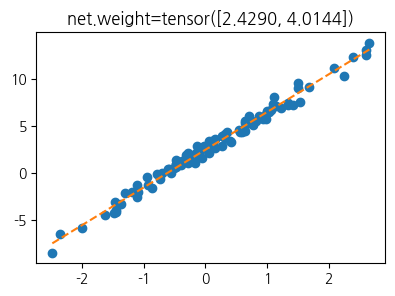

In [54]:
plt.plot(x,y,'o')
plt.plot(x,net(X).data,'--')
plt.title(f'net.weight={net.weight.data.reshape(-1)}');

#### D. Step4 update $\to$ `optimizer` 이용

`-` 기존의 방식

In [56]:
## -- 준비과정 -- ## 
# step1을 위한 사전준비
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    bias=False
)
net.weight.data = torch.tensor([[-5.0,  10.0]])
# step2를 위한 사전준비
loss_fn = torch.nn.MSELoss()

In [57]:
## -- 1에폭진행 -- ## 
# step1: 
yhat = net(X)
# step2: loss
loss = loss_fn(yhat,y)
# step3: 미분
loss.backward()
# step4: update
print(net.weight.data)
net.weight.data = net.weight.data - 0.1 * net.weight.grad
print(net.weight.data)
net.weight.grad = None

tensor([[-5., 10.]])
tensor([[-3.6577,  8.8111]])


In [58]:
## -- 2에폭진행 -- ## 
# step1: 2에폭진행
yhat = net(X)
# step2: loss
loss = loss_fn(yhat,y)
# step3: 미분
loss.backward()
# step4: update
print(net.weight.data)
net.weight.data = net.weight.data - 0.1 * net.weight.grad
print(net.weight.data)
net.weight.grad = None

tensor([[-3.6577,  8.8111]])
tensor([[-2.5548,  7.8612]])


`-` `optimizer` 이용한 코드

In [59]:
## -- 준비과정 -- ## 
# step1을 위한 사전준비
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    bias=False
)
net.weight.data = torch.tensor([[-5.0,  10.0]])
# step2를 위한 사전준비
loss_fn = torch.nn.MSELoss()
# step4를 위한 사전준비
optimizr = torch.optim.SGD(net.parameters(),lr=0.1) #이게 추가됨

In [60]:
## -- 1에폭진행 -- ## 
yhat = net(X)
# step2: loss
loss = loss_fn(yhat,y)
# step3: 미분
loss.backward()
# step4: update
print(net.weight.data)
#net.weight.data = net.weight.data - 0.1 * net.weight.grad
optimizr.step()
print(net.weight.data)
#net.weight.grad = None
optimizr.zero_grad()

tensor([[-5., 10.]])
tensor([[-3.6577,  8.8111]])


In [61]:
## -- 2에폭진행 -- ## 
yhat = net(X)
# step2: loss
loss = loss_fn(yhat,y)
# step3: 미분
loss.backward()
# step4: update
print(net.weight.data)
#net.weight.data = net.weight.data - 0.1 * net.weight.grad
optimizr.step()
print(net.weight.data)
#net.weight.grad = None
optimizr.zero_grad()

tensor([[-3.6577,  8.8111]])
tensor([[-2.5548,  7.8612]])


`-` 최종 `loss_fn`, `net`, `optimizer` 사용 코드

In [62]:
# step1을 위한 사전준비
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    bias=False
)
net.weight.data = torch.tensor([[-5.0,  10.0]])
# step2를 위한 사전준비
loss_fn = torch.nn.MSELoss()
# step4를 위한 사전준비 
optimizr = torch.optim.SGD(net.parameters(),lr=0.1)
for epoc in range(30):
    # step1: yhat 
    yhat = net(X)
    # step2: loss
    loss = loss_fn(yhat,y)
    # step3: 미분
    loss.backward()
    # step4: update
    optimizr.step()
    optimizr.zero_grad()

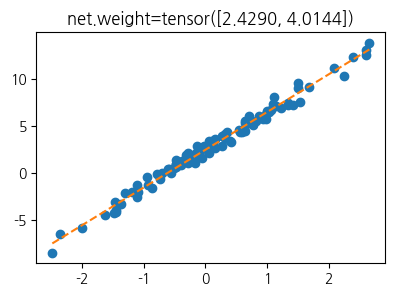

In [63]:
plt.plot(x,y,'o')
plt.plot(x,yhat.data,'--')
plt.title(f'net.weight={net.weight.data.reshape(-1)}');